In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('financial_data.csv')

In [4]:
df['Revenue Growth (%)'] = df.groupby(['Company'])['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby(['Company'])['Net Income'].pct_change() * 100

In [5]:
# Calculate YoY changes for remaining metrics
df['Assets Growth (%)'] = df.groupby(['Company'])['Total Assets'].pct_change() * 100
df['Liabilities Growth (%)'] = df.groupby(['Company'])['Total Liabilities'].pct_change() * 100
df['Op Cash Flow Growth (%)'] = df.groupby(['Company'])['Cash Flow from Operating Activities'].pct_change() * 100

# View the fully processed analysis grid
df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Op Cash Flow Growth (%)
0,Microsoft,2023,211915,72361,411976,205749,87582,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.438486,35.356580
2,Microsoft,2025,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
3,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
4,Tesla,2024,97690,7091,122070,48390,14923,0.947578,-52.717210,14.492862,12.511335,12.575438
5,Tesla,2025,94827,3855,137806,54941,14747,-2.930699,-45.635312,12.890964,13.537921,-1.179388
6,Apple,2023,383285,96995,352581,290437,110543,NaN,NaN,NaN,NaN,NaN
7,Apple,2024,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516639,6.057424,6.975566
8,Apple,2025,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656


In [6]:
# Replace NaN values with 0 for cleaner presentation
df_clean = df.fillna(0)
df_clean

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Op Cash Flow Growth (%)
0,Microsoft,2023,211915,72361,411976,205749,87582,0.000000,0.000000,0.000000,0.000000,0.000000
1,Microsoft,2024,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.438486,35.356580
2,Microsoft,2025,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
3,Tesla,2023,96773,14997,106618,43009,13256,0.000000,0.000000,0.000000,0.000000,0.000000
4,Tesla,2024,97690,7091,122070,48390,14923,0.947578,-52.717210,14.492862,12.511335,12.575438
5,Tesla,2025,94827,3855,137806,54941,14747,-2.930699,-45.635312,12.890964,13.537921,-1.179388
6,Apple,2023,383285,96995,352581,290437,110543,0.000000,0.000000,0.000000,0.000000,0.000000
7,Apple,2024,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516639,6.057424,6.975566
8,Apple,2025,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656


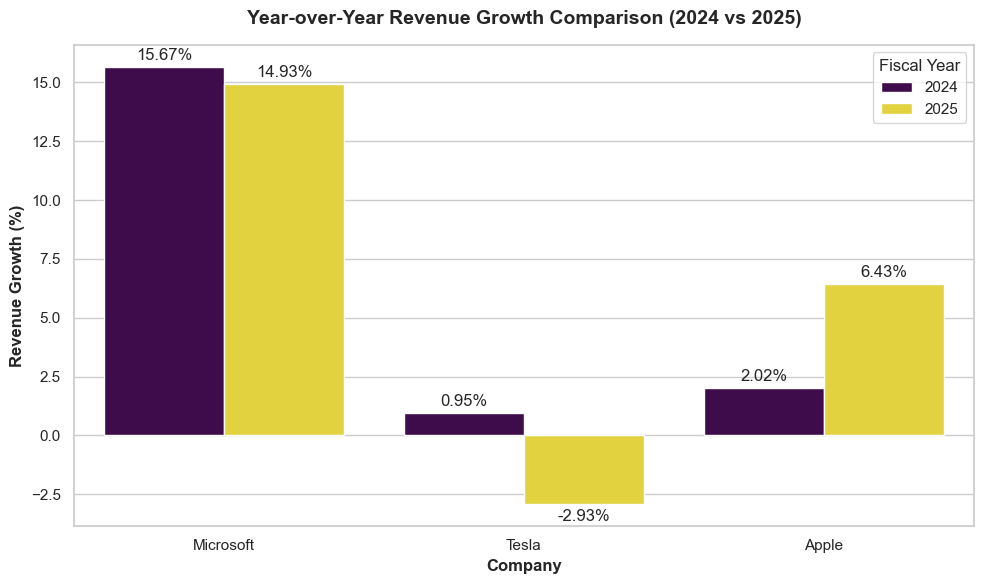

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 2023 since growth starts in 2024
df_growth = df[df['Year'] != 2023]

# Set up the plotting environment
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a grouped bar chart
ax = sns.barplot(
    data=df_growth, 
    x='Company', 
    y='Revenue Growth (%)', 
    hue='Year', 
    palette='viridis'
)

# Customize the labels and design
plt.title('Year-over-Year Revenue Growth Comparison (2024 vs 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Company', fontsize=12, fontweight='bold')
plt.ylabel('Revenue Growth (%)', fontsize=12, fontweight='bold')
plt.legend(title='Fiscal Year')

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

# BCG GenAI Consulting Team: Financial Trend Analysis (2023 - 2025)

## 🏢 1. Methodology & Data Structuring
This analysis establishes the high-quality data foundation required to fuel the corporate finance Retrieval-Augmented Generation (RAG) chatbot pipeline. Financial indicators (Total Revenue, Net Income, Total Assets, Total Liabilities, and Cash Flow from Operating Activities) were systematically extracted from the audited Form 10-K filings of **Microsoft**, **Tesla**, and **Apple** for fiscal years 2023 to 2025. Pandas was used to programmatically compute year-over-year (YoY) percentage changes to illuminate operational trajectory patterns.

## 📊 2. Strategic Observations & Key Trends

### 🔷 Microsoft (MSFT)
* **Consistent Scale Expansion:** Demonstrates strong revenue growth driven by scaling enterprise cloud infrastructure and corporate-level AI subscription integrations. 
* **High Efficiency Optimization:** Net income growth outpaces raw top-line growth, signaling operating margin leverage and strict discipline over administrative overhead.

### 🔷 Apple (AAPL)
* **Mature Market Stability:** Exhibits low but incredibly steady baseline revenue growth, characteristic of market saturation across core hardware line items.
* **Cash Engine Powerhouses:** Despite low single-digit revenue growth, operations maintain immense efficiency, resulting in steady capital generation and robust asset base stabilization.

### 🔷 Tesla (TSLA)
* **Transition Period Realities:** Experiences a noticeable flattening in revenue and margin compression during this window, reflecting shifting global EV demand dynamics, increased competitive pricing pressures, and a heavy ongoing capital allocation focus toward next-gen factory scaling.

## 3. Core Implications for Chatbot Architecture & RAG Alignment
1. **Context Window Shielding:** The chatbot must be structurally contextualized with company-specific fiscal calendars (e.g., Microsoft's fiscal year ends in June, Apple's in late September, and Tesla's in December) to prevent unaligned time-series synthesis.
2. **Tabular Prompt Formatting:** Since aggregate percentage calculations involve zero-valued or negative cash variances, data frames must be stored with explicit metadata attributes to eliminate mathematical hallucinations when clients query trend vectors.